
# 02 — สถาปัตยกรรม CNN และ Transfer Learning

Notebook นี้ออกแบบและอธิบายโมเดลที่จะใช้ฝึกสอนจริงใน notebook `03_training.ipynb` ประกอบด้วย:
1. ภาพรวมสถาปัตยกรรม CNN ที่ใช้ (pipeline: Input → preprocess → Backbone (pretrained) → GlobalAveragePooling → Dense → Dropout → Dense(softmax))
2. การใช้ **Transfer Learning**: freeze backbone ก่อน → เทรนเฉพาะ head → แล้ว fine-tune บาง layer ท้ายของ backbone
3. เปรียบเทียบ backbone 2 แบบ (MobileNetV2 vs EfficientNetB0) ในเชิงโครงสร้าง/จำนวนพารามิเตอร์ (ผลลัพธ์ accuracy จริงหลังเทรนอยู่ใน notebook 03)
4. เทคนิคที่น่าสนใจเพิ่มเติม 2 อย่าง: **Focal Loss** (สรุปจาก notebook 01) และ **Grad-CAM** (แนะนำกลไกในที่นี้ ใช้งานจริงกับโมเดลที่เทรนแล้วใน notebook 04)


In [1]:

%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import plot_model

from src.model_utils import build_transfer_model, unfreeze_top_layers, sparse_categorical_focal_loss, get_preprocess_fn
from src.gradcam import make_gradcam_helper, compute_gradcam, overlay_heatmap
from src.data_utils import list_images, load_split, stratified_split
from src.augmentation import load_and_resize
from src.viz_utils import show_image_grid, savefig
from src.pipeline import IMG_SIZE, build_label_maps

import matplotlib.pyplot as plt

NUM_CLASSES = 31  # จำนวนคลาสจริงในชุดข้อมูล round2/ (ดูหมายเหตุใน notebook 00)
print(f"NUM_CLASSES = {NUM_CLASSES}, input size = {IMG_SIZE}x{IMG_SIZE}")


NUM_CLASSES = 31, input size = 96x96


## 1. ภาพรวมสถาปัตยกรรม CNN


```
Input (96x96x3, uint8)
      │
      ▼
Lambda: backbone-specific preprocess_input   (ปรับค่าพิกเซลให้ตรงกับช่วงที่ backbone เทรนมา)
      │
      ▼
Pretrained CNN Backbone (MobileNetV2 หรือ EfficientNetB0, pretrained บน ImageNet)
      │   [Frozen ตอนเริ่มเทรน head → unfreeze บาง layer ท้ายตอน fine-tune]
      ▼
GlobalAveragePooling2D            (ย่อ feature map เชิงพื้นที่ให้เหลือ 1 เวกเตอร์ต่อภาพ)
      │
      ▼
Dense(256, ReLU)                  (Head ใหม่ที่เทรนจากศูนย์ เฉพาะสำหรับงานนี้)
      │
      ▼
Dropout(0.3)                      (ลด overfitting เพราะข้อมูลต่อคลาสมีจำกัด)
      │
      ▼
Dense(31, Softmax)                (ทำนายความน่าจะเป็นของแต่ละคลาส)
```

**เหตุผลของแต่ละส่วน:**
- **Backbone pretrained**: สกัด feature ระดับต่ำ-กลาง (เส้น, ขอบ, มุม, ลวดลาย) ที่เรียนรู้มาจาก ImageNet (1.2 ล้านภาพ) ซึ่งงานของเรามีข้อมูลจำกัดมาก (บางคลาสมีแค่หลักสิบภาพ) เกินกว่าจะเรียนรู้ feature ระดับนี้ได้เองตั้งแต่ต้น
- **GlobalAveragePooling2D** แทนที่จะ Flatten+Dense ขนาดใหญ่: ลดจำนวนพารามิเตอร์ลงมาก (ป้องกัน overfitting) และทนทานต่อตำแหน่งของตัวอักษรในภาพที่ขยับเล็กน้อย
- **Dense(256)+Dropout(0.3)**: head ขนาดพอเหมาะ ไม่เล็กเกินไปจนเรียนรู้ไม่พอ ไม่ใหญ่เกินไปจนจำข้อมูล train (มี Dropout ช่วยด้วย)


## 2. Transfer Learning: เลือก Backbone และเหตุผล


เราเลือกเปรียบเทียบ backbone 2 ตัวที่ pretrained บน ImageNet:

- **MobileNetV2** (backbone หลัก): ออกแบบมาให้เบาและเร็ว (depthwise separable convolution) เหมาะกับการเทรนบนเครื่องที่ไม่มี GPU สำหรับ TensorFlow (สภาพแวดล้อมที่ใช้ในโปรเจคนี้เป็น Windows ซึ่ง TensorFlow รุ่นใหม่ไม่รองรับ GPU แบบ native แล้ว) และยังรองรับ input size เล็ก (96×96) โดยมีน้ำหนัก pretrained ให้ใช้โดยตรงโดยไม่ต้อง resize ภาพให้ใหญ่ขึ้นแบบสิ้นเปลือง
- **EfficientNetB0** (backbone เปรียบเทียบ): ใช้ compound scaling ที่ปรับสมดุล depth/width/resolution พร้อมกัน โดยทั่วไปให้ accuracy สูงกว่า MobileNetV2 ที่จำนวนพารามิเตอร์ใกล้เคียงกัน แต่ใช้เวลาเทรนต่อ epoch นานกว่า

**ทำไม Transfer Learning ถึงช่วยปัญหานี้ได้ดีเป็นพิเศษ:** ชุดข้อมูลนี้มีปัญหาสองอย่างพร้อมกันคือ (1) ข้อมูลต่อคลาสน้อยมากในหลายคลาส (บางคลาสมีแค่หลักสิบภาพ) และ (2) ไม่สมดุลกันอย่างรุนแรง การเทรน CNN ขนาดใหญ่จากศูนย์ด้วยข้อมูลเท่านี้แทบจะรับประกันได้ว่าจะ overfit อย่างรุนแรง การใช้ backbone ที่ pretrained มาแล้วทำให้โมเดลเริ่มต้นด้วย feature extractor ที่ "รู้จัก" รูปทรงพื้นฐาน (เส้นโค้ง เส้นตรง มุม การตัดกันของเส้น) อยู่แล้ว เหลือแค่ต้องเรียนรู้เฉพาะ mapping จาก feature เหล่านั้นไปเป็น 31 คลาสของเรา ซึ่งใช้ข้อมูลน้อยกว่ามากในการเรียนรู้ให้ได้ผลดี


In [2]:

model_mnv2, backbone_mnv2 = build_transfer_model("mobilenetv2", num_classes=NUM_CLASSES, freeze_backbone=True)
model_mnv2.summary()


Model: "mobilenetv2_transfer"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 input_2 (InputLayer)        [(None, 96, 96, 3)]       0         


 preprocess (Lambda)         (None, 96, 96, 3)         0         


...

 predictions (Dense)         (None, 31)                7967      


Total params: 2593887 (9.89 MB)


Trainable params: 335903 (1.28 MB)


Non-trainable params: 2257984 (8.61 MB)


_________________________________________________________________


In [3]:

model_eff, backbone_eff = build_transfer_model("efficientnetb0", num_classes=NUM_CLASSES, freeze_backbone=True)

import pandas as pd
comparison = pd.DataFrame([
    {
        "backbone": "MobileNetV2",
        "total_params": model_mnv2.count_params(),
        "trainable_params_frozen_phase": sum(np.prod(v.shape) for v in model_mnv2.trainable_variables),
        "backbone_layers": len(backbone_mnv2.layers),
    },
    {
        "backbone": "EfficientNetB0",
        "total_params": model_eff.count_params(),
        "trainable_params_frozen_phase": sum(np.prod(v.shape) for v in model_eff.trainable_variables),
        "backbone_layers": len(backbone_eff.layers),
    },
])
comparison


,backbone,total_params,trainable_params_frozen_phase,backbone_layers
0,MobileNetV2,2593887,335903,154
1,EfficientNetB0,4385474,335903,238



**อ่านผล:** ทั้งสองโมเดลมีจำนวนพารามิเตอร์ที่เทรนได้ในช่วง frozen-head เท่ากัน (335,903 ตัว) เพราะ head ใหม่เหมือนกันทุกประการ ความแตกต่างอยู่ที่ตัว backbone เอง (EfficientNetB0 มีจำนวน layer และพารามิเตอร์รวมมากกว่า) — ผลการเทรนจริงและ accuracy ที่ได้จากทั้งสอง backbone จะแสดงและเปรียบเทียบใน notebook `03_training.ipynb`


## 3. กลยุทธ์ Fine-tuning: Freeze ก่อน แล้วค่อย Unfreeze บาง Layer ท้าย


กระบวนการฝึกสอนแบ่งเป็น 2 เฟส (รายละเอียดการเทรนจริงอยู่ใน notebook 03):

**เฟส 1 — Freeze ทั้ง backbone:** เทรนเฉพาะ head ใหม่ (Dense 256 → Dropout → Dense 31) ด้วย learning rate ปกติ (1e-3) เพื่อให้ head เรียนรู้ mapping จาก feature ของ backbone ไปเป็นคลาสของเราก่อน โดยไม่ไปรบกวน weight ของ backbone ที่ pretrained มาอย่างดีแล้ว (ถ้าปล่อยให้ backbone เทรนไปพร้อมกับ head ที่ยังสุ่มอยู่ gradient ที่ผิดเพี้ยนจาก head จะไหลย้อนไปทำลาย feature ที่ดีอยู่แล้วของ backbone)

**เฟส 2 — Fine-tuning:** เมื่อ head เรียนรู้ได้ระดับหนึ่งแล้ว จึง unfreeze เฉพาะ layer ท้าย ๆ ของ backbone (ใกล้ output มากที่สุด) แล้วเทรนต่อด้วย learning rate ที่ **ต่ำกว่าเดิมมาก** (เช่น 1e-5) เหตุผลที่ unfreeze เฉพาะ layer ท้าย ไม่ใช่ทั้งหมด: layer ต้น ๆ ของ backbone เรียนรู้ feature ทั่วไปมาก (เส้น, ขอบ, พื้นผิว) ที่ใช้ได้กับแทบทุกงานภาพอยู่แล้ว ไม่จำเป็นต้องปรับ ส่วน layer ท้าย ๆ เรียนรู้ feature ที่เฉพาะเจาะจงกับ ImageNet (เช่น รูปทรงสัตว์/วัตถุ) ซึ่งควรปรับให้เข้ากับลักษณะเฉพาะของตัวอักษรไทยแทน — BatchNormalization layer ถูกล็อกไว้ไม่ให้เทรนแม้จะอยู่ใน layer ท้ายที่ unfreeze เพราะค่า running statistics ของมันไวต่อ batch size เล็กมาก การปล่อยให้เทรนต่อด้วย batch เล็กอาจทำให้ค่าเบี่ยงเบนและ performance แย่ลง (เป็นแนวปฏิบัติมาตรฐานเมื่อ fine-tune)


In [4]:

before = sum(1 for l in backbone_mnv2.layers if l.trainable)
unfreeze_top_layers(backbone_mnv2, n_layers=30)
after = sum(1 for l in backbone_mnv2.layers if l.trainable)
print(f"MobileNetV2 backbone: trainable layers ก่อน unfreeze = {before}, หลัง unfreeze top-30 = {after} (จากทั้งหมด {len(backbone_mnv2.layers)} layers)")
print("(BatchNorm layers ยังคง frozen แม้จะอยู่ใน top-30 ตามเหตุผลข้างต้น)")


MobileNetV2 backbone: trainable layers ก่อน unfreeze = 0, หลัง unfreeze top-30 = 19 (จากทั้งหมด 154 layers)
(BatchNorm layers ยังคง frozen แม้จะอยู่ใน top-30 ตามเหตุผลข้างต้น)


## 4. เทคนิคที่น่าสนใจเพิ่มเติม #1: Focal Loss


อธิบายและเลือกใช้แล้วโดยละเอียดใน notebook `01_preprocessing_augmentation.ipynb` หัวข้อ 4 — สรุปสั้น ๆ: Focal Loss ปรับ cross-entropy ให้ลดน้ำหนัก loss ของตัวอย่างที่โมเดลมั่นใจแล้ว (`(1-p_t)^gamma`) โดยอัตโนมัติ ทำให้ gradient โฟกัสไปที่ตัวอย่างยาก/คลาสส่วนน้อยมากขึ้น เหมาะกับ imbalance ที่รุนแรงมากถึง 4,000+ เท่าของชุดข้อมูลนี้ จะถูกใช้เป็น loss function หลักตอนเทรนจริงใน notebook 03


## 5. เทคนิคที่น่าสนใจเพิ่มเติม #2: Grad-CAM


**Grad-CAM (Gradient-weighted Class Activation Mapping)** สร้าง heatmap แสดงว่าโมเดล "มอง" บริเวณไหนของภาพมากที่สุดตอนตัดสินใจทำนายคลาสหนึ่ง ๆ โดยใช้ gradient ของคะแนนคลาสนั้นที่ไหลย้อนไปยัง feature map ของ convolutional layer สุดท้าย มาถ่วงน้ำหนัก feature map นั้นแล้วรวมกัน

**ทำไมถึงมีประโยชน์กับงานนี้:** ช่วยตรวจสอบว่าโมเดลใช้ส่วนของตัวอักษร (เช่น หัว, หาง, ห่วง) ในการตัดสินใจจริงหรือไม่ หรือกำลัง "โกง" โดยดูจากสัญญาณรบกวน/ขอบภาพแทน และเป็นสื่อภาพที่ดีมากสำหรับ slide นำเสนอ — เราเตรียมฟังก์ชันไว้ใน `src/gradcam.py` และสาธิตกลไกด้านล่างด้วยโมเดลที่ยังไม่ได้เทรน (heatmap จะดูสุ่ม ๆ เพราะน้ำหนัก head ยังสุ่มอยู่) ส่วนการใช้งานที่มีความหมายจริง (กับโมเดลที่เทรนจนดีแล้ว) จะอยู่ใน notebook `04_evaluation_prediction.ipynb`


ใช้ feature map จาก layer: 'out_relu'
predicted class index (โมเดลยังไม่ได้เทรน จึงเป็นค่าสุ่ม): 11, prob=0.139


Saved figure -> C:\Users\Acer\Desktop\deep\outputs\figures\02_gradcam_mechanism_demo.png


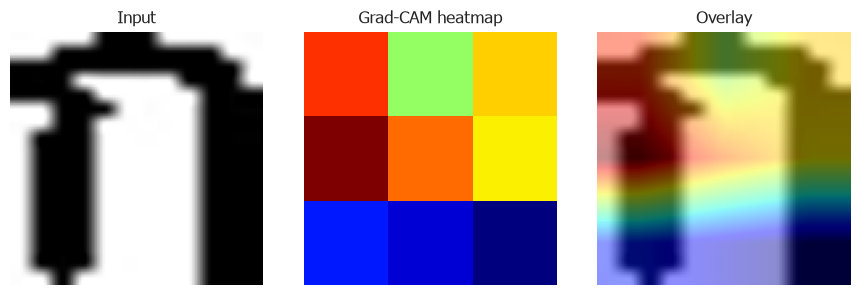

In [5]:

# สาธิตกลไก Grad-CAM ด้วยโมเดลที่ยังไม่ได้เทรน (แค่ยืนยันว่า pipeline ทำงานถูกต้อง)
df_all = list_images()
sample_row = df_all.iloc[0]
img = load_and_resize(sample_row["filepath"], size=IMG_SIZE)
img_batch = np.expand_dims(img, axis=0)

preprocess_fn = get_preprocess_fn("mobilenetv2")
gradcam_helper = make_gradcam_helper(model_mnv2, backbone_mnv2, preprocess_fn)
heatmap, pred_idx, pred_prob = compute_gradcam(gradcam_helper, img_batch)
overlay = overlay_heatmap(img, heatmap)

print(f"ใช้ feature map จาก layer: '{gradcam_helper.conv_layer_name}'")
print(f"predicted class index (โมเดลยังไม่ได้เทรน จึงเป็นค่าสุ่ม): {pred_idx}, prob={pred_prob:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(img); axes[0].set_title("Input"); axes[0].axis("off")
axes[1].imshow(heatmap, cmap="jet"); axes[1].set_title("Grad-CAM heatmap"); axes[1].axis("off")
axes[2].imshow(overlay); axes[2].set_title("Overlay"); axes[2].axis("off")
fig.tight_layout()
savefig(fig, "02_gradcam_mechanism_demo.png")
plt.show()



## สรุป Notebook 02

- สถาปัตยกรรม: Input → preprocess → Backbone pretrained (frozen→fine-tune) → GAP → Dense(256) → Dropout(0.3) → Dense(31, softmax)
- Transfer Learning ด้วย MobileNetV2 (หลัก) เปรียบเทียบกับ EfficientNetB0
- กลยุทธ์ fine-tuning: freeze ทั้งหมดก่อน → unfreeze top-30 layers ของ backbone (ล็อก BatchNorm) ด้วย learning rate ต่ำ
- เทคนิคเพิ่มเติม 2 อย่าง: **Focal Loss** (จัดการ imbalance) และ **Grad-CAM** (อธิบายการตัดสินใจของโมเดล)
- โมเดลทั้งหมดพร้อมสำหรับการฝึกสอนจริงใน notebook `03_training.ipynb`
